In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


def get_all_metrics():
    metrics = Path("../results/metrics")

    allFiles=[file for file in metrics.glob("*_metrics.csv") if file.name!= "all_metrics.csv"]


    combine_df = pd.concat(
        [pd.read_csv(file) for file in allFiles],
        ignore_index=True
    )

    combine_df.to_csv("../results/metrics/all_metrics.csv", index=False)
    return combine_df

combine_df = get_all_metrics()
print(combine_df)

                 model  accuracy  precision_macro  recall_macro  f1_macro  \
0                  KNN  0.933333         0.899749      0.918182  0.906205   
1  logistic_regression  0.946667         0.921727      0.925758  0.919978   
2        random_forest  0.960000         0.936975      0.934722  0.935214   

    roc_auc  
0  0.994493  
1  0.985625  
2  0.996047  


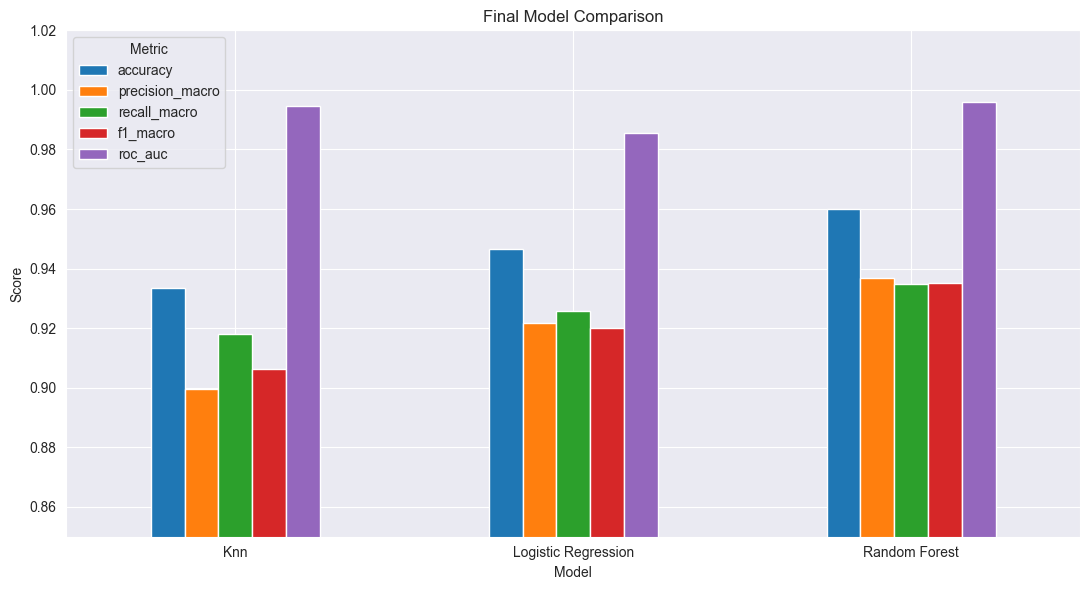

In [18]:
def plot_final_comparison(df):
    metric_cols = [
        col for col in
        ["accuracy", "precision_macro", "recall_macro", "f1_macro", "roc_auc"]
        if col in df.columns
    ]

    plot_df = df[["model"] + metric_cols].copy()

    # Make model names cleaner for the graph
    plot_df["model"] = (
        plot_df["model"]
        .astype(str)
        .str.replace("_", " ", regex=False)
        .str.title()
    )

    ax = plot_df.set_index("model").plot(kind="bar", figsize=(11, 6))
    ax.set_title("Final Model Comparison")
    ax.set_xlabel("Model")
    ax.set_ylabel("Score")
    ax.set_ylim(0.85, 1.02)
    plt.xticks(rotation=0)
    plt.legend(title="Metric")
    plt.tight_layout()

    plt.savefig("../results/metrics/final_model_comparison.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
combined_df = get_all_metrics()
plot_final_comparison(combined_df)

Random Forest performed best overall, achieving the highest scores on nearly all evaluation metrics. Logistic Regression was the second-best model and remained competitive across the metrics. KNN had the lowest overall predictive performance, although its ROC-AUC was still high.